# Model Training

## Imports & Configuration

In [1]:
import torch
import torchvision
from torchvision import transforms
import os
import json
import random
import numpy as np
import cv2
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

import torchvision.models as models
import torchvision.transforms as T

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4080


## Dataset & Dataloader

In [3]:
os.chdir("..")

In [4]:
DATASET_PATH = "data/dataset"

MODEL_PATH = "weights"
METRICS_PATH = "metrics"

os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(METRICS_PATH, exist_ok=True)

## Augmentation

In [5]:
def augment_image(img):

    h, w = img.shape[:2]

    # Horizontal flip
    if np.random.rand() < 0.5:
        img = cv2.flip(img, 1)

    # Rotation
    if np.random.rand() < 0.5:
        angle = np.random.uniform(-15, 15)
        M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1)
        rotation = cv2.warpAffine(img, M, (w, h))
        rotate_crop = rotation[25:h-25, 25:w-25]
        img = cv2.resize(rotate_crop, (w, h))

    # Brightness
    if np.random.rand() < 0.5:
        img = cv2.convertScaleAbs(img, alpha=1, beta=40)

    # Contrast
    if np.random.rand() < 0.5:
        img = cv2.convertScaleAbs(img, alpha=1.5, beta=0)

    # Zoom
    if np.random.rand() < 0.5:
        crop = img[40:h-40, 40:w-40]
        img = cv2.resize(crop, (w, h))

    return img

## Dataset & Dataloader

In [6]:
class LandmarkDataset(Dataset):

    def __init__(self, samples, labels, augment=False):
        self.samples = samples
        self.labels = labels
        self.augment = augment

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        img_path = self.samples[idx]
        label = self.labels[idx]

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.augment:
            img = augment_image(img)
            alpha = np.random.uniform(0.8, 1.2)  # contrast
            beta = np.random.uniform(-20, 20)    # brightness
            img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

        img = img / 255.0
        img = np.transpose(img, (2,0,1))

        img = torch.tensor(img, dtype=torch.float32)

        return img, label

In [52]:
class_names = sorted(os.listdir(DATASET_PATH))

class_to_idx = {cls:i for i,cls in enumerate(class_names)}

samples = []
labels = []

for cls in class_names:
    folder = os.path.join(DATASET_PATH, cls)
    for img_name in os.listdir(folder):
        samples.append(os.path.join(folder, img_name))
        labels.append(class_to_idx[cls])

In [20]:
samples[:5], samples[50:55]

(['data/dataset\\Big_Ben\\Big_Ben_1.jpg',
  'data/dataset\\Big_Ben\\Big_Ben_10.jpg',
  'data/dataset\\Big_Ben\\Big_Ben_11.jpg',
  'data/dataset\\Big_Ben\\Big_Ben_12.jpg',
  'data/dataset\\Big_Ben\\Big_Ben_13.jpg'],
 ['data/dataset\\Christ_The_Redeemer\\Christ_The_Redeemer_1.jpg',
  'data/dataset\\Christ_The_Redeemer\\Christ_The_Redeemer_10.jpg',
  'data/dataset\\Christ_The_Redeemer\\Christ_The_Redeemer_11.jpg',
  'data/dataset\\Christ_The_Redeemer\\Christ_The_Redeemer_12.jpg',
  'data/dataset\\Christ_The_Redeemer\\Christ_The_Redeemer_13.jpg'])

In [21]:
labels[:5], labels[50:55]

([0, 0, 0, 0, 0], [1, 1, 1, 1, 1])

### Train/Val split

In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    samples,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=SEED
)

### Dataloader

In [9]:
train_dataset = LandmarkDataset(X_train, y_train, augment=True)
val_dataset = LandmarkDataset(X_val, y_val, augment=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

## Baseline Model (Simple CNN)

In [58]:
class BaselineCNN(nn.Module): # Custom VGG

    def __init__(self, num_classes):
      super().__init__()

      # 224 * 224 * 3
      self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels = 3, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))

      # 112 * 112 * 64
      self.layer2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))

      # 56 * 56 * 128
      self.layer3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Dropout(0.25))
      
      # 1 * 1 * 256
      self.fc1 = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(1 * 1 * 256, 512),
            nn.ReLU())
      self.fc2 = nn.Linear(in_features=512, out_features=num_classes)
    
    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = torch.flatten(out, 1)
        out = self.fc1(out)
        out = self.fc2(out)

        return out

### Training Loop

In [12]:
def train_epoch(model, loader, criterion, optimizer):

    model.train()

    losses = []

    for imgs, labels in loader:

        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(imgs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        losses.append(loss.item())

    return np.mean(losses)

### Validation

In [13]:
def validate_epoch(model, loader, criterion):

    model.eval()

    losses = []

    with torch.no_grad():

        for imgs, labels in loader:

            imgs = imgs.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(imgs)

            loss = criterion(outputs, labels)

            losses.append(loss.item())

    return np.mean(losses)

### Count Metrics

In [14]:
def evaluate_metrics(model, loader):
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    
    return acc, f1

### Train

In [32]:
EPOCHS = 20

train_losses = []
val_losses = []
val_accuracies = []
val_f1s = []

baseline = BaselineCNN(num_classes=len(class_names)).to(DEVICE)
total_params = sum(p.numel() for p in baseline.parameters())
print(f"Model params: {total_params}")

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(baseline.parameters(), lr=1e-4)

for epoch in range(EPOCHS):

    train_loss = train_epoch(baseline, train_loader, criterion, optimizer)
    val_loss = validate_epoch(baseline, val_loader, criterion)
    
    acc, f1 = evaluate_metrics(baseline, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(acc)
    val_f1s.append(f1)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"val_acc={acc:.3f} | val_f1={f1:.3f}"
    )

Model params: 1283914
Epoch 1/20 | train_loss=2.2814 | val_loss=2.2889 | val_acc=0.100 | val_f1=0.028
Epoch 2/20 | train_loss=2.1958 | val_loss=2.1423 | val_acc=0.260 | val_f1=0.184
Epoch 3/20 | train_loss=2.1443 | val_loss=2.0994 | val_acc=0.290 | val_f1=0.230
Epoch 4/20 | train_loss=2.1018 | val_loss=2.0991 | val_acc=0.240 | val_f1=0.205
Epoch 5/20 | train_loss=2.0697 | val_loss=1.9897 | val_acc=0.290 | val_f1=0.223
Epoch 6/20 | train_loss=2.0385 | val_loss=1.9890 | val_acc=0.270 | val_f1=0.204
Epoch 7/20 | train_loss=2.0219 | val_loss=1.9896 | val_acc=0.260 | val_f1=0.198
Epoch 8/20 | train_loss=2.0036 | val_loss=1.9398 | val_acc=0.320 | val_f1=0.262
Epoch 9/20 | train_loss=1.9742 | val_loss=1.9825 | val_acc=0.300 | val_f1=0.237
Epoch 10/20 | train_loss=1.9711 | val_loss=1.8777 | val_acc=0.360 | val_f1=0.290
Epoch 11/20 | train_loss=1.9594 | val_loss=1.9288 | val_acc=0.280 | val_f1=0.254
Epoch 12/20 | train_loss=1.8952 | val_loss=1.8655 | val_acc=0.350 | val_f1=0.291
Epoch 13/20 | t

#### Plots

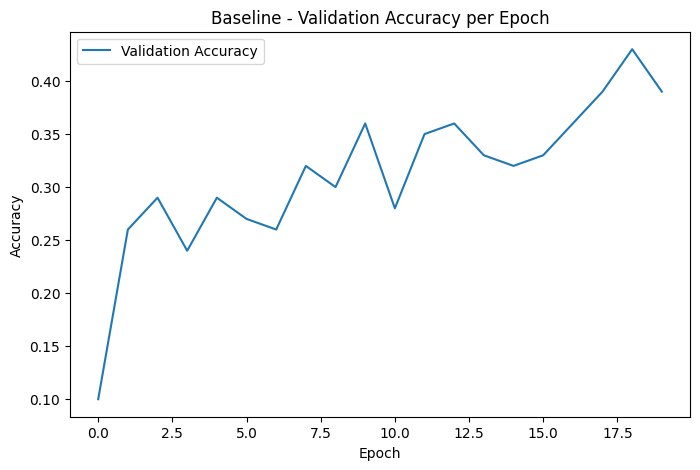

In [41]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline - Validation Accuracy per Epoch")
plt.legend()
plt.savefig("metrics/artifacts/Baseline-accuracy_curve.png")
plt.show()

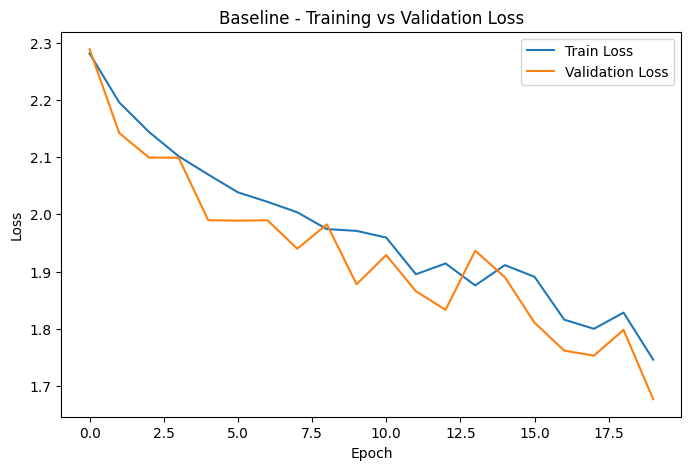

In [42]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline - Training vs Validation Loss")

plt.legend()

plt.savefig("metrics/artifacts/Baseline-loss_curve.png")

plt.show()

#### Save Baseline model

In [35]:
torch.save(baseline.state_dict(), "weights/baseline_model.pth")

In [21]:
def save_metrics_json(
    model, 
    model_name: str, 
    num_classes: int, 
    train_loss: list, 
    val_loss: list, 
    val_accuracy: list, 
    val_f1: list, 
    notes: str = "", 
    save_path: str = "metrics/metrics.json"
):

    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    metrics_dict = {
        "model_name": model_name,
        "num_params": num_params,
        "num_classes": num_classes,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
        "val_f1": val_f1,
        "notes": notes
    }

    with open(save_path, "w") as f:
        json.dump(metrics_dict, f, indent=4)

    print(f"Metrics saved to {save_path}")

In [38]:
save_metrics_json(
    model=baseline,
    model_name="BaselineCNN (Changed VGG)",
    num_classes=10,
    train_loss=train_losses,
    val_loss=val_losses,
    val_accuracy=val_accuracies,
    val_f1=val_f1s,
    notes="Baseline CNN (Changed VGG) with 3 conv layers and fc1=512",
    save_path="metrics/baseline_metrics.json"
)

Metrics saved to metrics/baseline_metrics.json


In [40]:
import pandas as pd

baseline_metrics = pd.read_json("metrics/baseline_metrics.json")

baseline_metrics.head()

,model_name,num_params,num_classes,train_loss,val_loss,val_accuracy,val_f1,notes
0,BaselineCNN (Changed VGG),1283914,10,2.281397,2.288889,0.10,0.028348,Baseline CNN (Changed VGG) with 3 conv layers ...
1,BaselineCNN (Changed VGG),1283914,10,2.195824,2.142298,0.26,0.184357,Baseline CNN (Changed VGG) with 3 conv layers ...
2,BaselineCNN (Changed VGG),1283914,10,2.144282,2.099362,0.29,0.229514,Baseline CNN (Changed VGG) with 3 conv layers ...
3,BaselineCNN (Changed VGG),1283914,10,2.101777,2.099131,0.24,0.204680,Baseline CNN (Changed VGG) with 3 conv layers ...
4,BaselineCNN (Changed VGG),1283914,10,2.069665,1.989707,0.29,0.222795,Baseline CNN (Changed VGG) with 3 conv layers ...


#### Classification example using simple model

C:\Users\User\AppData\Local\Temp\ipykernel_28256\3473862784.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  baseline.load_state_dict(torch.load(BASELINE_WEIGHTS, map_lo

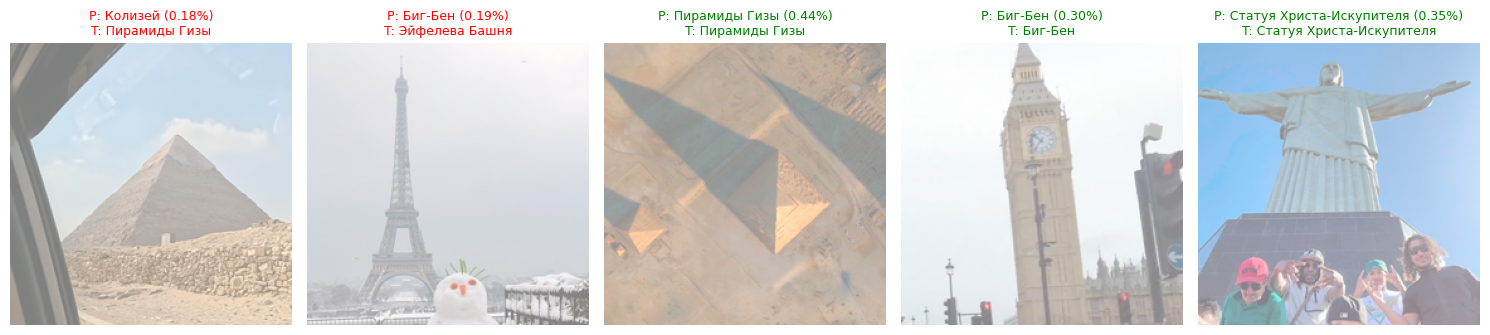

In [62]:
import torch.nn.functional as F


BASELINE_WEIGHTS = "weights/baseline_model.pth"
CLASS_NAMES_JSON = "data/class_names.json"
DESCRIPTIONS_JSON = "data/descriptions.json"
DATASET_DIR = "data/dataset"

with open(CLASS_NAMES_JSON, "r", encoding="utf-8") as f:
    class_names_dict = json.load(f)  

with open(DESCRIPTIONS_JSON, "r", encoding="utf-8") as f:
    descriptions_dict = json.load(f)

baseline = BaselineCNN(num_classes=10)
baseline.load_state_dict(torch.load(BASELINE_WEIGHTS, map_location=DEVICE))
baseline.to(DEVICE)
baseline.eval()


val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=1, shuffle=False)

plt.figure(figsize=(15,5))

for i, (img, label) in enumerate(val_loader):
    if i >= 5:
        break

    img = img.to(DEVICE)

    with torch.no_grad():
        outputs = baseline(img)
        probs = F.softmax(outputs, dim=1)
        pred_idx = torch.argmax(outputs, dim=1).item()
        pred_prob = probs[0, pred_idx].item()

    pred_folder = class_names[pred_idx]  
    true_folder = class_names[label.item()] 

    human_name = class_names_dict[pred_folder]
    pred_desc  = descriptions_dict[pred_folder]
    true_name  = class_names_dict[true_folder]

    img_np = img.squeeze(0).permute(1,2,0).cpu().numpy()
    img_np = (img_np * 0.5 + 0.5)

    color = "green" if pred_idx == label.item() else "red"

    plt.subplot(1,5,i+1)
    plt.imshow(img_np)
    plt.title(f"P: {human_name} ({pred_prob:.2f}%)\nT: {true_name}", color=color, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Transfer Learning (MobileNetV2)

In [27]:
mobilenet_model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

for param in mobilenet_model.features.parameters():
    param.requires_grad = False

in_features = mobilenet_model.classifier[1].in_features

mobilenet_model.classifier[1] = nn.Linear(in_features, len(class_names))

model = mobilenet_model.to(DEVICE)

### Training Loop

In [28]:
EPOCHS = 30

train_losses = []
val_losses = []
val_accuracies = []
val_f1s = []

trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

print(f"Trainable params: {trainable_params}")

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(mobilenet_model.parameters(), lr=1e-4)

for epoch in range(EPOCHS):

    train_loss = train_epoch(mobilenet_model, train_loader, criterion, optimizer)
    val_loss = validate_epoch(mobilenet_model, val_loader, criterion)
    
    acc, f1 = evaluate_metrics(mobilenet_model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(acc)
    val_f1s.append(f1)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"val_acc={acc:.3f} | val_f1={f1:.3f}"
    )

Trainable params: 12810
Epoch 1/30 | train_loss=2.2912 | val_loss=2.2314 | val_acc=0.180 | val_f1=0.176
Epoch 2/30 | train_loss=2.2334 | val_loss=2.1718 | val_acc=0.330 | val_f1=0.316
Epoch 3/30 | train_loss=2.1609 | val_loss=2.1144 | val_acc=0.460 | val_f1=0.446
Epoch 4/30 | train_loss=2.1031 | val_loss=2.0571 | val_acc=0.570 | val_f1=0.566
Epoch 5/30 | train_loss=2.0667 | val_loss=2.0012 | val_acc=0.700 | val_f1=0.694
Epoch 6/30 | train_loss=2.0170 | val_loss=1.9556 | val_acc=0.670 | val_f1=0.662
Epoch 7/30 | train_loss=1.9483 | val_loss=1.9039 | val_acc=0.790 | val_f1=0.786
Epoch 8/30 | train_loss=1.8962 | val_loss=1.8465 | val_acc=0.840 | val_f1=0.834
Epoch 9/30 | train_loss=1.8493 | val_loss=1.8126 | val_acc=0.840 | val_f1=0.836
Epoch 10/30 | train_loss=1.8149 | val_loss=1.7666 | val_acc=0.810 | val_f1=0.799
Epoch 11/30 | train_loss=1.7710 | val_loss=1.7030 | val_acc=0.860 | val_f1=0.858
Epoch 12/30 | train_loss=1.7190 | val_loss=1.6740 | val_acc=0.830 | val_f1=0.829
Epoch 13/30 |

#### Plots

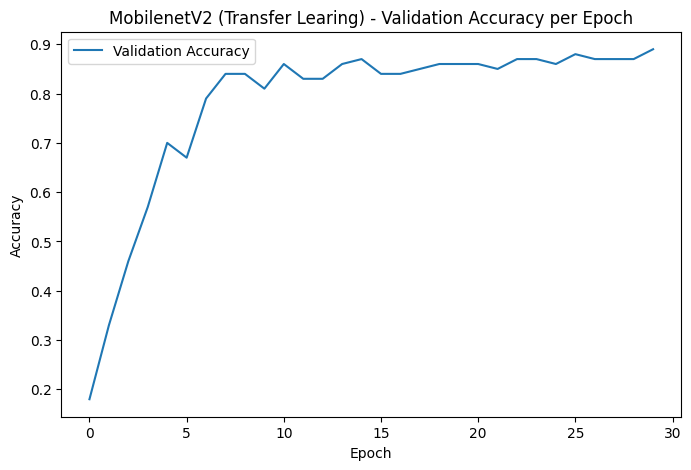

In [29]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobilenetV2 (Transfer Learing) - Validation Accuracy per Epoch")
plt.legend()
plt.savefig("metrics/artifacts/MobilenetV2-accuracy_curve.png")
plt.show()

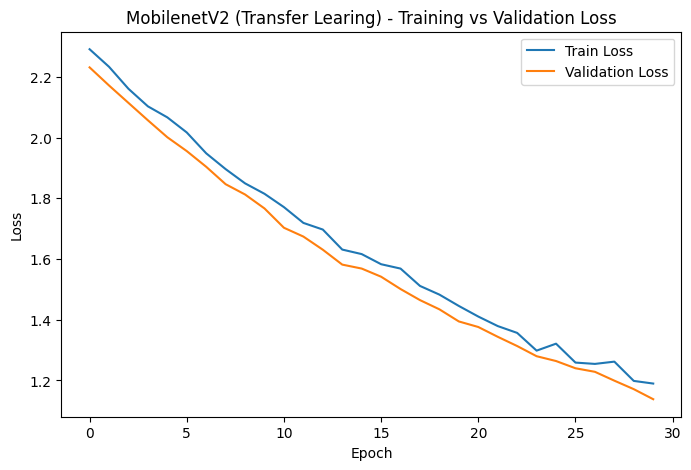

In [30]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobilenetV2 (Transfer Learing) - Training vs Validation Loss")

plt.legend()

plt.savefig("metrics/artifacts/MobilenetV2-loss_curve.png")

plt.show()

### Save Transfer Learning Model

In [31]:
torch.save(model.state_dict(), "weights/mobilenet_transfer.pth")

In [32]:
save_metrics_json(
    model=mobilenet_model,
    model_name="MobilenetV2 (TransferLearning)",
    num_classes=10,
    train_loss=train_losses,
    val_loss=val_losses,
    val_accuracy=val_accuracies,
    val_f1=val_f1s,
    notes="MobilenetV2 (TransferLearning) with 12810 Trainable params in last layer",
    save_path="metrics/mobilenet_metrics.json"
)

Metrics saved to metrics/mobilenet_metrics.json


In [33]:
import pandas as pd

mobilenet_metrics = pd.read_json("metrics/mobilenet_metrics.json")

mobilenet_metrics.head()

,model_name,num_params,num_classes,train_loss,val_loss,val_accuracy,val_f1,notes
0,MobilenetV2 (TransferLearning),12810,10,2.291241,2.231436,0.18,0.175629,MobilenetV2 (TransferLearning) with 12810 Trai...
1,MobilenetV2 (TransferLearning),12810,10,2.233365,2.171786,0.33,0.315711,MobilenetV2 (TransferLearning) with 12810 Trai...
2,MobilenetV2 (TransferLearning),12810,10,2.160891,2.114399,0.46,0.445813,MobilenetV2 (TransferLearning) with 12810 Trai...
3,MobilenetV2 (TransferLearning),12810,10,2.103086,2.057088,0.57,0.566338,MobilenetV2 (TransferLearning) with 12810 Trai...
4,MobilenetV2 (TransferLearning),12810,10,2.066713,2.001235,0.70,0.694349,MobilenetV2 (TransferLearning) with 12810 Trai...


### Classification example using MobilenetV2 model

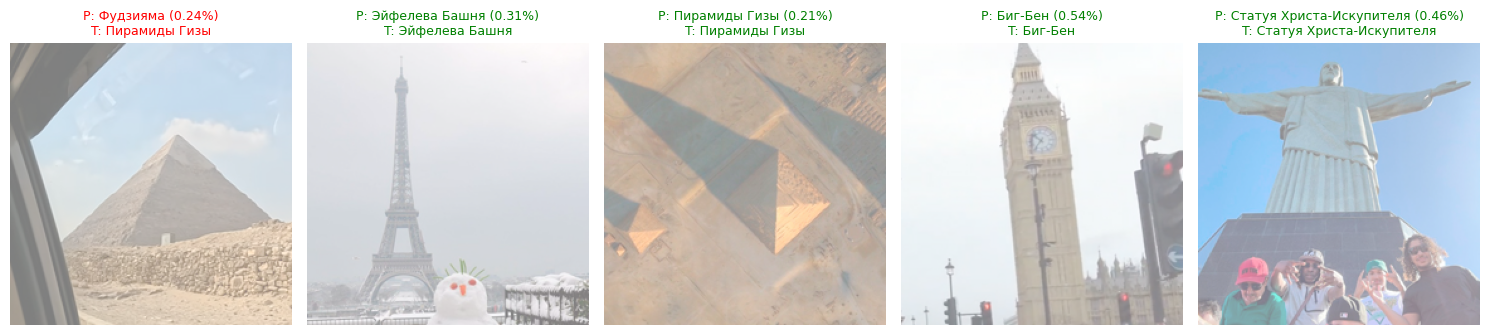

In [61]:
import torch.nn.functional as F

CLASS_NAMES_JSON = "data/class_names.json"
DESCRIPTIONS_JSON = "data/descriptions.json"
DATASET_DIR = "data/dataset"

with open(CLASS_NAMES_JSON, "r", encoding="utf-8") as f:
    class_names_dict = json.load(f)  

with open(DESCRIPTIONS_JSON, "r", encoding="utf-8") as f:
    descriptions_dict = json.load(f)


val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=1, shuffle=False)

plt.figure(figsize=(15,5))

for i, (img, label) in enumerate(val_loader):
    if i >= 5:
        break

    img = img.to(DEVICE)

    with torch.no_grad():
        outputs = mobilenet_model(img)
        probs = F.softmax(outputs, dim=1)
        pred_idx = torch.argmax(outputs, dim=1).item()
        pred_prob = probs[0, pred_idx].item()

    pred_folder = class_names[pred_idx]  
    true_folder = class_names[label.item()] 

    human_name = class_names_dict[pred_folder]
    pred_desc  = descriptions_dict[pred_folder]
    true_name  = class_names_dict[true_folder]

    img_np = img.squeeze(0).permute(1,2,0).cpu().numpy()
    img_np = (img_np * 0.5 + 0.5)

    color = "green" if pred_idx == label.item() else "red"

    plt.subplot(1,5,i+1)
    plt.imshow(img_np)
    plt.title(f"P: {human_name} ({pred_prob:.2f}%)\nT: {true_name}", color=color, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()